In [2]:
# ===================== Cell 1: 环境配置与数据加载 =====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import pdist
import re
from pathlib import Path

# 路径配置 (根据实际项目结构调整)
ENRICH_DIR = Path("../results/enrichment")
FIG_DIR = Path("../figures/week10")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# 加载第九周生成的矩阵
nes_mat = pd.read_csv(ENRICH_DIR / "pathway_nes_matrix.tsv", sep="\t", index_col=0)
fdr_mat = pd.read_csv(ENRICH_DIR / "pathway_fdr_matrix.tsv", sep="\t", index_col=0)
print(f"✅ 数据加载完成: NES矩阵 {nes_mat.shape}, FDR矩阵 {fdr_mat.shape}")

✅ 数据加载完成: NES矩阵 (363, 7), FDR矩阵 (2025, 7)


In [3]:
# ===================== Cell 2: 通路冗余聚类与上位主题归并 =====================
# 1. 填充NaN为0用于相似性计算
nes_filled = nes_mat.fillna(0)

# 2. 基于NES向量相关性计算距离矩阵
corr = nes_filled.T.corr()
dist = 1 - corr.values
np.fill_diagonal(dist, 0)

# 3. 层次聚类
linkage_mat = linkage(dist, method='average')

# 4. 动态切割聚类树 (阈值0.5对应相关性>0.5)
clusters = fcluster(linkage_mat, t=0.5, criterion='distance')
nes_mat['Cluster'] = clusters

# 5. 选择每个聚类的代表性通路 (平均|NES|最大)
rep_terms = []
for cid in sorted(nes_mat['Cluster'].unique()):
    terms = nes_mat[nes_mat['Cluster'] == cid].index
    mean_abs = nes_mat.loc[terms].abs().mean(axis=1)
    rep_terms.append(mean_abs.idxmax())

print(f"🎯 {len(nes_mat)} 条原始通路 → {len(rep_terms)} 个上位主题")

# 保存映射表
mapping = nes_mat[['Cluster']].reset_index()
mapping.columns = ['Pathway', 'Cluster_ID']
mapping.to_csv(ENRICH_DIR / "pathway_cluster_mapping.tsv", sep='\t', index=False)

🎯 363 条原始通路 → 61 个上位主题


In [8]:
# ===================== Cell 3 (最终修复版): 模块识别 =====================
SIG_FDR = 0.05

# 1. 彻底清洗
fdr_clean = fdr_mat.fillna(1.0).replace([np.inf, -np.inf], 1.0)
nes_clean = nes_mat.fillna(0).replace([np.inf, -np.inf], 0)

# 2. 确保 rep_terms 全部存在于矩阵索引中
valid_terms = [t for t in rep_terms if t in sig_mask.index]
missing = set(rep_terms) - set(valid_terms)
if missing:
    print(f"⚠️ {len(missing)} 个代表通路不在矩阵索引中，已跳过")

# 3. 提取组织列表
tissues = sorted(set(c.split('__')[0] for c in nes_clean.columns))
print(f"📋 检测到 {len(tissues)} 种组织: {tissues}")

module_stats = []
for term in valid_terms:
    # 【核心修复】不用布尔掩码索引，改用显式条件筛选列名
    row_fdr = fdr_clean.loc[term]
    row_nes = nes_clean.loc[term]
    
    # 找出同时满足 FDR<0.05 且 |NES|>0 的列名
    sig_cols = row_fdr[row_fdr < SIG_FDR].index.intersection(
               row_nes[row_nes.abs() > 0].index)
    
    active_tissues = set()
    for col in sig_cols:
        tissue = col.split('__')[0]
        if row_nes[col] > 0:
            active_tissues.add(tissue)
    
    n_tissues = len(active_tissues)
    module_type = "Shared" if n_tissues >= len(tissues) * 0.7 else \
                  "Specific" if n_tissues == 1 else "Partial"
    
    module_stats.append({
        'Representative_Term': term,
        'N_Active_Tissues': n_tissues,
        'Module_Type': module_type,
        'Active_Tissues': '|'.join(sorted(active_tissues))
    })

module_df = pd.DataFrame(module_stats).set_index('Representative_Term')
module_df.to_csv(ENRICH_DIR / "module_classification.tsv", sep='\t')

print("\n📊 模块分类统计:")
print(module_df['Module_Type'].value_counts())
print(f"\n✅ 共 {len(module_df)} 个上位主题完成分类")

📋 检测到 8 种组织: ['Cluster', 'Heart_and_Aorta', 'Heart_and_Aorta_fibroblast', 'Kidney', 'Kidney_fibroblast', 'Liver', 'Lung', 'Lung_fibroblast']

📊 模块分类统计:
Module_Type
Partial     52
Specific     9
Name: count, dtype: int64

✅ 共 61 个上位主题完成分类


🎯 正在绘制 61 个代表性通路
📊 共有列数: 7
✅ 最终矩阵维度: NES (61, 7), FDR (61, 7)


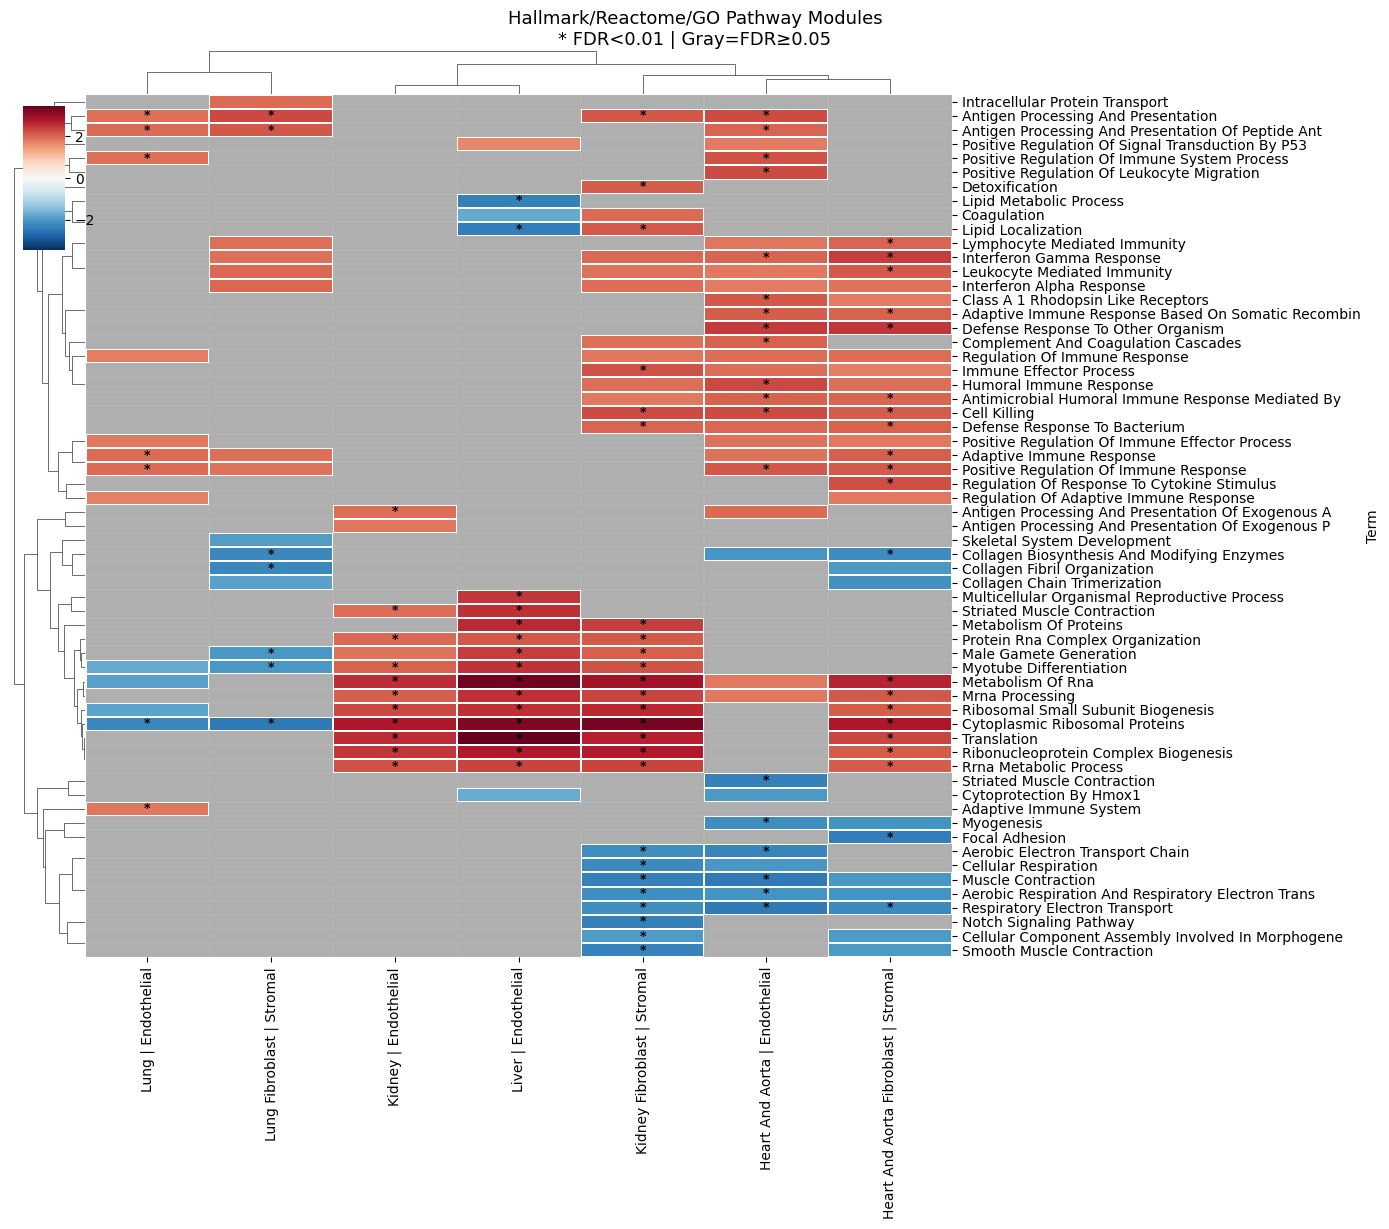

✅ Fig3 已保存


In [11]:
# ===================== Cell 4 (终极修复版): Fig3 带聚类树的热图 =====================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.colors import TwoSlopeNorm
import re

# 1. 确定要绘制的通路列表 (rep_terms)
try:
    if 'module_df' in globals():
        rep_terms = module_df.index.tolist()
    elif 'nes_mat_dedup' in globals():
        rep_terms = nes_mat_dedup.index.tolist()
    else:
        # Fallback: Top 50 by min FDR
        min_fdr = fdr_mat.min(axis=1)
        rep_terms = min_fdr.nsmallest(50).index.tolist()
except Exception:
    min_fdr = fdr_mat.min(axis=1)
    rep_terms = min_fdr.nsmallest(50).index.tolist()

print(f"🎯 正在绘制 {len(rep_terms)} 个代表性通路")

# 2. 【核心修复】从原始矩阵中提取数据，并确保列名完全一致
# 获取两个矩阵共有的列名 (交集)
common_cols = nes_mat.columns.intersection(fdr_mat.columns)
print(f"📊 共有列数: {len(common_cols)}")

# 提取行 (rep_terms) 和列 (common_cols)
# 使用 .reindex 确保即使某些通路缺失也不会报错，而是填充 NaN
nes_sub = nes_mat.reindex(index=rep_terms, columns=common_cols)
fdr_sub = fdr_mat.reindex(index=rep_terms, columns=common_cols)

# 删除全为 NaN 的行 (如果某些代表通路在所有节点都缺失)
nes_sub.dropna(how='all', inplace=True)
fdr_sub.dropna(how='all', inplace=True)

# 再次确认索引同步 (以防 dropna 后不同步)
common_idx = nes_sub.index.intersection(fdr_sub.index)
nes_sub = nes_sub.loc[common_idx]
fdr_sub = fdr_sub.loc[common_idx]

print(f"✅ 最终矩阵维度: NES {nes_sub.shape}, FDR {fdr_sub.shape}")
assert nes_sub.shape == fdr_sub.shape, "维度仍不匹配！请检查数据源"

# 3. 清洗数据
nes_clean = nes_sub.fillna(0).replace([np.inf, -np.inf], 0)
fdr_clean = fdr_sub.fillna(1.0).replace([np.inf, -np.inf], 1.0)

# 4. 名称美化函数
def clean_term(name):
    name = re.sub(r'^(GOBP_|REACTOME_|WP_|HALLMARK_)', '', name)
    return name.replace('_', ' ').title()[:50]

def clean_node(node):
    parts = node.split('__')
    if len(parts) == 2:
        return f"{parts[0].replace('_',' ').title()} | {parts[1].replace('_',' ').title()}"
    return node.replace('_', ' ').title()

# 5. 应用美化 (使用 rename 而不是直接赋值，更安全)
nes_clean = nes_clean.rename(index=clean_term, columns=clean_node)
fdr_clean = fdr_clean.rename(index=clean_term, columns=clean_node)

# 6. 显著性掩码
SIG_FDR = 0.05
sig_mask = fdr_clean.values < SIG_FDR

# 7. 对称色标
vmax = max(abs(nes_clean.values.min()), abs(nes_clean.values.max())) or 1.0
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

# 8. 绘制 clustermap
g = sns.clustermap(
    nes_clean, 
    cmap='RdBu_r', 
    norm=norm,
    figsize=(14, 12), 
    metric='correlation', 
    method='average',
    row_cluster=True, 
    col_cluster=True,
    dendrogram_ratio=(0.08, 0.05),
    cbar_pos=(0.02, 0.82, 0.03, 0.12),
    linewidths=0.3, 
    linecolor='white',
    xticklabels=True, 
    yticklabels=True
)

# 9. 叠加显著性标记
ax = g.ax_heatmap
r_idx = g.dendrogram_row.reordered_ind
c_idx = g.dendrogram_col.reordered_ind

sig_r = sig_mask[r_idx][:, c_idx]
fdr_r = fdr_clean.values[r_idx][:, c_idx]

for i in range(len(r_idx)):
    for j in range(len(c_idx)):
        if not sig_r[i, j]:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, facecolor='gray', alpha=0.6, edgecolor='none'))
        if fdr_r[i, j] < 0.01:
            ax.text(j + 0.5, i + 0.5, '*', ha='center', va='center', fontsize=9, fontweight='bold')

g.fig.suptitle('Hallmark/Reactome/GO Pathway Modules\n* FDR<0.01 | Gray=FDR≥0.05', fontsize=13, y=1.02)
g.savefig(FIG_DIR / "Fig3_pathway_modules.pdf", bbox_inches='tight', dpi=300)
g.savefig(FIG_DIR / "Fig3_pathway_modules.png", bbox_inches='tight', dpi=300)
plt.show()
print("✅ Fig3 已保存")

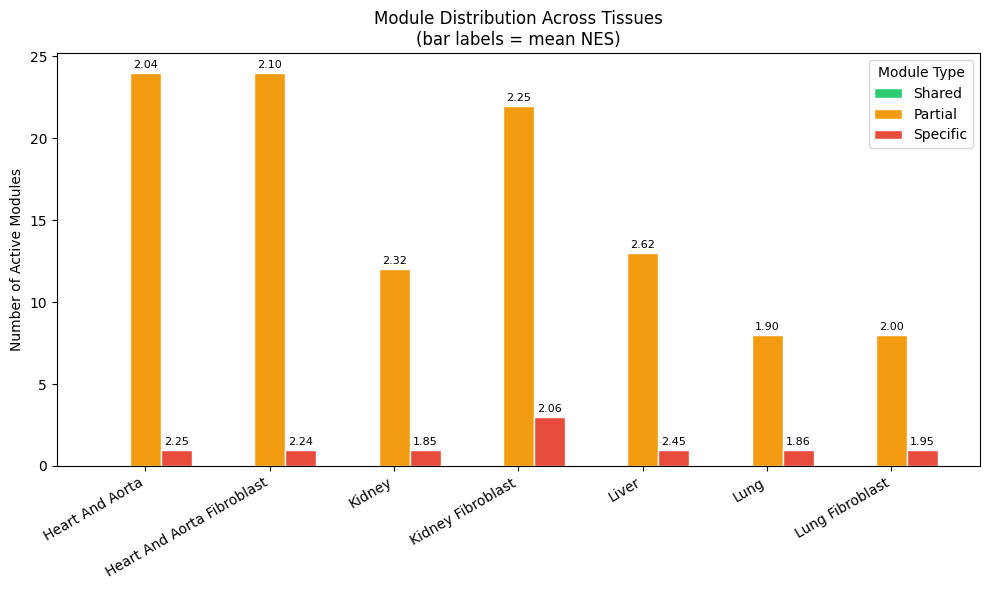

✅ 模块分布图已保存


In [12]:
# ===================== Cell 5: 补充图 - 模块类型分布气泡图 =====================
# 展示各组织中 Shared/Specific/Partial 模块的数量和平均效应量
bubble_data = []
for _, row in module_df.iterrows():
    tissues_list = row['Active_Tissues'].split('|') if row['Active_Tissues'] else []
    for t in tissues_list:
        term = row.name
        nes_val = nes_mat.loc[term].filter(like=t).mean()
        bubble_data.append({
            'Tissue': t.replace('_', ' ').title(),
            'Module_Type': row['Module_Type'],
            'Mean_NES': nes_val,
            'Count': 1
        })

bdf = pd.DataFrame(bubble_data)
pivot_count = bdf.pivot_table(index='Tissue', columns='Module_Type', values='Count', aggfunc='sum').fillna(0)
pivot_nes = bdf.pivot_table(index='Tissue', columns='Module_Type', values='Mean_NES', aggfunc='mean').fillna(0)

fig, ax = plt.subplots(figsize=(10, 6))
types = ['Shared', 'Partial', 'Specific']
colors = ['#2ecc71', '#f39c12', '#e74c3c']
x_pos = np.arange(len(pivot_count.index))
width = 0.25

for idx, mtype in enumerate(types):
    counts = pivot_count.get(mtype, pd.Series(0, index=pivot_count.index))
    bars = ax.bar(x_pos + idx*width, counts, width, label=mtype, color=colors[idx], edgecolor='white')
    # 在柱子上标注平均NES
    for bar, val in zip(bars, pivot_nes.get(mtype, pd.Series(0, index=pivot_count.index))):
        if val != 0:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, 
                   f'{val:.2f}', ha='center', fontsize=8)

ax.set_xticks(x_pos + width)
ax.set_xticklabels(pivot_count.index, rotation=30, ha='right')
ax.set_ylabel('Number of Active Modules')
ax.set_title('Module Distribution Across Tissues\n(bar labels = mean NES)')
ax.legend(title='Module Type')
plt.tight_layout()
plt.savefig(FIG_DIR / "Supp_module_distribution.pdf", bbox_inches='tight', dpi=300)
plt.show()
print("✅ 模块分布图已保存")